# 07_PXRD_Pattern_Stacking_SSA

### Developed by SSA to make stack plots of PXRD patterns

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Location to  processed .xy files 

data_folder = "E:/CBZ/"    # folder containing your .xy files
outfile_excel = os.path.join(data_folder, "07_Pir_ref_comp_stacked_patterns.xlsx")
outfile_png = os.path.join(data_folder, "07_Pir_ref_comp_stacked_patterns.png")

two_theta_min = 4.0
two_theta_max = 30.0
two_theta_step = 0.02

normalize = True       # scale each pattern to max = 1
offset_step = 1.25      # vertical offset between stacked patterns
baseline_window = 51    # rolling median window for background removal (None to disable)

In [3]:
#define refernce patterns to be put at bottom of stack plot 

reference_keywords = [] #["DOLBIR", "Monoclinic", "Orthorhombic", "sample", "sim", "ref", "calc", "theory", "mercury"] 
# any file with one of these words in its name will be treated as a reference pattern

# Optional manual plotting order (bottom -> top).
# Use filename stems (partial match allowed).
pattern_order_bottom_to_top = [
    "DLM Alpha ref",
    "DLM Beta ref",
    "DL-Methionine 0.079VF (EtOH)",
    "DL-Methionine 0.05VF (H2O)",

    ]

In [4]:
#Functions
def read_xy(filepath):
    """Read a 2-column .xy file, skipping any headers."""
    x, y = [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
            except ValueError:
                continue
    return np.array(x), np.array(y)

def rolling_median(y, window=51):
    """Simple rolling median baseline."""
    s = pd.Series(y)
    baseline = s.rolling(window, center=True, min_periods=1).median()
    return baseline.to_numpy()


⚠️ These manual order entries were not matched: ['DLM Alpha ref', 'DLM Beta ref', 'DL-Methionine 0.079VF (EtOH)', 'DL-Methionine 0.05VF (H2O)']


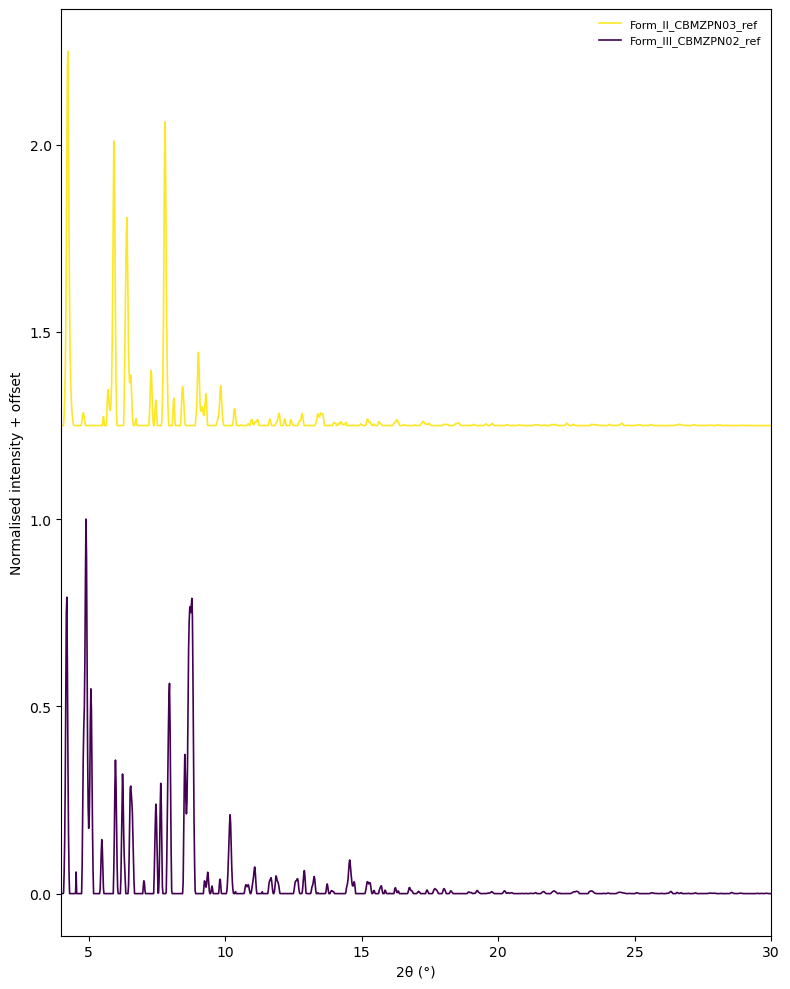


✅ Exported stacked Excel: E:/CBZ/07_Pir_ref_comp_stacked_patterns.xlsx
✅ Saved figure with legend: E:/CBZ/07_Pir_ref_comp_stacked_patterns.png


In [5]:
filelist = sorted(glob.glob(os.path.join(data_folder, "*.xy")) + 
                  glob.glob(os.path.join(data_folder, "*.txt")))

if not filelist:
    raise SystemExit(f"No .xy or .txt files found in {data_folder}")

def apply_manual_order(files, order_tokens):
    """Reorder files using user list (bottom -> top)."""
    if not order_tokens:
        return files

    ordered = []
    remaining = files.copy()
    unmatched = []

    for token in order_tokens:
        token_low = token.lower()
        matches = [
            f for f in remaining
            if token_low in os.path.splitext(os.path.basename(f))[0].lower()
        ]
        if not matches:
            unmatched.append(token)
            continue
        for m in matches:
            ordered.append(m)
            remaining.remove(m)

    if unmatched:
        print(f"⚠️ These manual order entries were not matched: {unmatched}")

    return ordered + remaining

# Split into reference and experimental based on keywords
ref_files = [f for f in filelist if any(k.lower() in os.path.basename(f).lower() for k in reference_keywords)]
exp_files = [f for f in filelist if f not in ref_files]

# Default order: references first (bottom), then experimental
default_order = ref_files + exp_files

# Manual override: first item = bottom, last item = top
ordered_files = apply_manual_order(default_order, pattern_order_bottom_to_top)

grid = np.arange(two_theta_min, two_theta_max, two_theta_step)
df = pd.DataFrame({"2theta": grid})

plt.figure(figsize=(8, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(ordered_files)))
handles, labels = [], []

for i, fpath in enumerate(ordered_files):
    name = os.path.splitext(os.path.basename(fpath))[0]
    x, y = read_xy(fpath)
    if len(x) == 0:
        print(f"⚠️ Skipping {name} (no data read)")
        continue

    # interpolate onto common grid
    y_interp = np.interp(grid, x, y, left=0, right=0)

    # baseline correction
    if baseline_window:
        baseline = rolling_median(y_interp, baseline_window)
        y_corr = np.clip(y_interp - baseline, 0, None)
    else:
        y_corr = y_interp

    # normalize
    if normalize and y_corr.max() > 0:
        y_corr /= y_corr.max()

    # save to DataFrame
    df[name] = y_corr

    # decide if reference
    is_ref = fpath in ref_files
    style = '--' if is_ref else '-'
    color = "red" if is_ref else colors[i]

    # plot stacked
    line, = plt.plot(grid, y_corr + i * offset_step, style, color=color, label=name, linewidth=1.2)
    handles.append(line)
    labels.append(name)

# --- Legend ---
# Reverse so legend order matches stack appearance (top pattern first, bottom last)
plt.legend(handles[::-1], labels[::-1], loc='upper right', fontsize=8, frameon=False)

# --- Figure formatting ---
plt.xlabel("2θ (°)")
plt.ylabel("Normalised intensity + offset")
plt.xlim(two_theta_min, two_theta_max)
plt.tight_layout()
plt.savefig(outfile_png, dpi=300)
plt.show()

# --- Export combined data ---
df.to_excel(outfile_excel, index=False)
print(f"\n✅ Exported stacked Excel: {outfile_excel}")
print(f"✅ Saved figure with legend: {outfile_png}")